In [2]:
!pip install transformers sentencepiece torch torchvision pillow

  Using cached transformers-5.10.2-py3-none-any.whl.metadata (33 kB)
  Using cached regex-2026.5.9-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
Using cached transformers-5.10.2-py3-none-any.whl (11.0 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 3.0 MB/s  0:00:00
Using cached regex-2026.5.9-cp313-cp313-win_amd64.whl (277 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

   ---------------------------------------- 0/5 [sentencepiece]
   -------- ------------------------


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from transformers import TrOCRProcessor
from transformers import VisionEncoderDecoderModel

from PIL import Image

import torch

In [4]:
MODEL_NAME = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(
    MODEL_NAME
)

model = VisionEncoderDecoderModel.from_pretrained(
    MODEL_NAME
)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model.to(device)

print(device)

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

c:\Users\Rasulbekk\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Rasulbekk\.cache\huggingface\hub\models--microsoft--trocr-base-handwritten. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

cpu


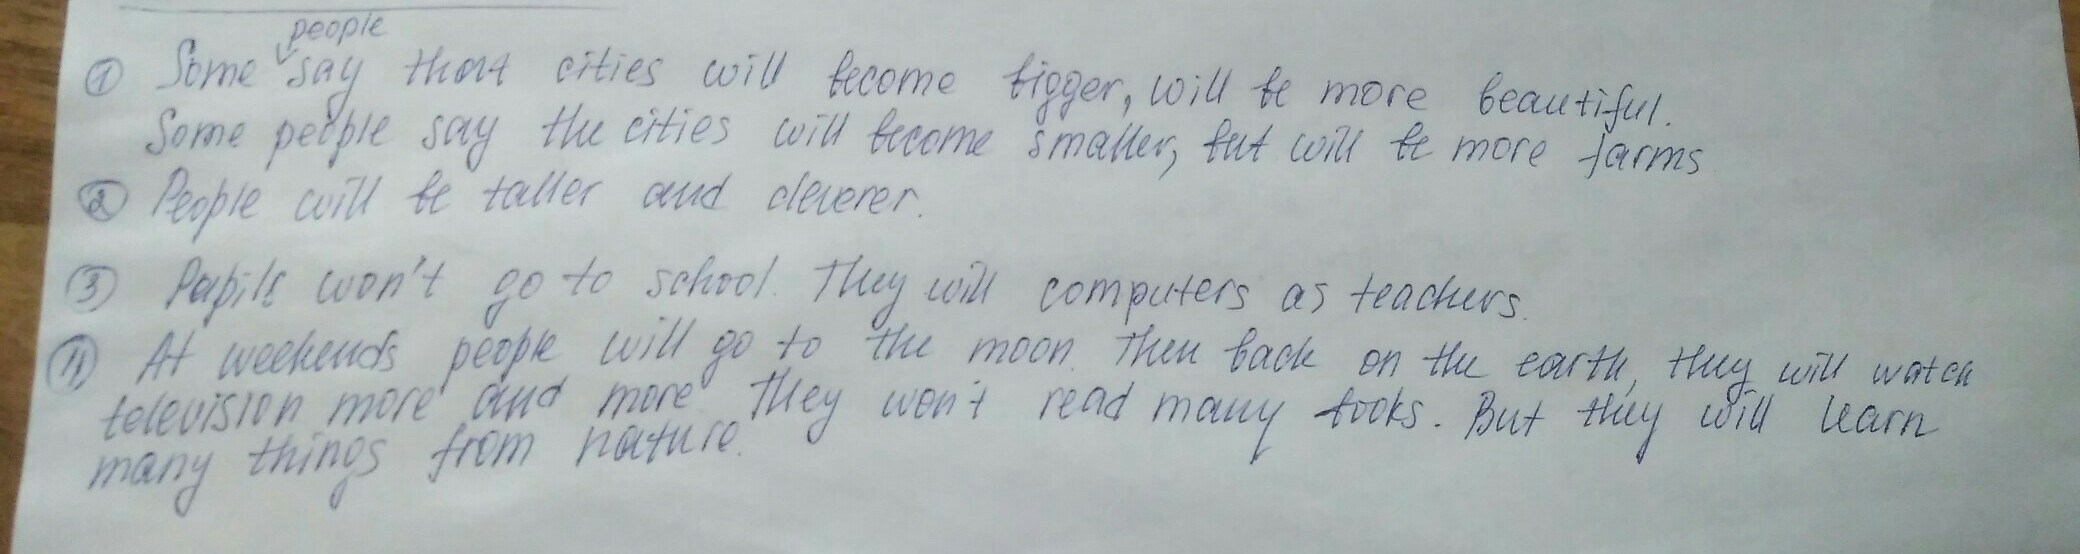

In [5]:
image = Image.open(

    "../data/raw/essay001.jpg"

).convert("RGB")

image

In [6]:
pixel_values = processor(

    image,

    return_tensors="pt"

).pixel_values

pixel_values = pixel_values.to(
    device
)

In [7]:
generated_ids = model.generate(

    pixel_values,

    max_length=512

)

In [8]:
text = processor.batch_decode(

    generated_ids,

    skip_special_tokens=True

)[0]

print(text)

Pleasant Sea


In [10]:
import os

os.makedirs("../data/texts", exist_ok=True)

print("texts papkasi yaratildi")

texts papkasi yaratildi


In [11]:
with open(

    "../data/texts/essay001.txt",

    "w",

    encoding="utf-8"

) as f:

    f.write(text)

print("Saved")

Saved


In [12]:
import os

for file in os.listdir("../data/raw"):

    if file.endswith(".jpg"):

        image = Image.open(

            os.path.join(

                "../data/raw",

                file

            )

        ).convert("RGB")

        pixel_values = processor(

            image,

            return_tensors="pt"

        ).pixel_values.to(device)

        generated_ids = model.generate(

            pixel_values,

            max_length=512

        )

        text = processor.batch_decode(

            generated_ids,

            skip_special_tokens=True

        )[0]

        txt_name = file.replace(

            ".jpg",

            ".txt"

        )

        with open(

            os.path.join(

                "../data/texts",

                txt_name

            ),

            "w",

            encoding="utf-8"

        ) as f:

            f.write(text)

        print(file, "OK")

essay001.jpg OK
essay002.jpg OK
essay003.jpg OK
essay004.jpg OK
essay005.jpg OK
essay006.jpg OK
essay007.jpg OK
essay008.jpg OK
essay009.jpg OK
essay010.jpg OK


In [13]:
import os

text_folder = r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\texts"

for file in sorted(os.listdir(text_folder)):

    if file.endswith(".txt"):

        print("="*50)
        print(file)

        with open(
            os.path.join(text_folder, file),
            "r",
            encoding="utf-8"
        ) as f:

            print(f.read()[:500])

        print()

essay001.txt
Pleasant Sea

essay002.txt
0 0000

essay003.txt
0 0

essay004.txt
0 0000

essay005.txt
topping the

essay006.txt
0 0000

essay007.txt
0 0

essay008.txt
0 1

essay009.txt
0 0

essay010.txt
1961 02 25 25



In [14]:
import os
import pandas as pd

image_folder = r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\raw"

text_folder = r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\texts"

rows = []

for image_file in sorted(os.listdir(image_folder)):

    if image_file.endswith(".jpg"):

        txt_file = image_file.replace(".jpg", ".txt")

        txt_path = os.path.join(
            text_folder,
            txt_file
        )

        with open(
            txt_path,
            "r",
            encoding="utf-8"
        ) as f:

            text = f.read().strip()

        rows.append({

            "image":
            os.path.join(
                image_folder,
                image_file
            ),

            "text":
            text

        })

df = pd.DataFrame(rows)

os.makedirs(
    r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\annotations",
    exist_ok=True
)

save_path = r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\annotations\train.csv"

df.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

print(df.head())

print()
print("Saved :", save_path)

                                               image          text
0  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...  Pleasant Sea
1  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...        0 0000
2  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...           0 0
3  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...        0 0000
4  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...   topping the

Saved : C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\annotations\train.csv


In [15]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\annotations\train.csv")

print(df.head())
print(df.columns)
print(df.shape)

                                               image          text
0  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...  Pleasant Sea
1  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...        0 0000
2  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...           0 0
3  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...        0 0000
4  C:\Users\Rasulbekk\Desktop\ielts_handwriting_o...   topping the
Index(['image', 'text'], dtype='str')
(10, 2)


In [16]:
import os

IMAGE_DIR = r"C:\Users\Rasulbekk\Desktop\ielts_handwriting_ocr\data\images"

df["image_path"] = df["image"].apply(lambda x: os.path.join(IMAGE_DIR, x))

In [17]:
import cv2

def check_image(path):
    img = cv2.imread(path)
    return img is not None

df["valid"] = df["image_path"].apply(check_image)

df = df[df["valid"] == True]
print("Clean dataset size:", len(df))

Clean dataset size: 10


In [18]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

print(len(train_df), len(val_df))

9 1


In [19]:
from torch.utils.data import Dataset
from PIL import Image

class OCRDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df = dataframe
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        text = row["text"]

        encoding = self.processor(
            images=image,
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(),
            "labels": encoding["labels"].squeeze()
        }

In [20]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

In [22]:
!pip install gradio transformers torch pillow


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=False)
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=False)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=30

In [24]:
def ocr_image(image):
    if image is None:
        return "Rasm topilmadi"

    # PIL format
    image = image.convert("RGB")

    # preprocess
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    # generate text
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return text

In [25]:
import gradio as gr

interface = gr.Interface(
    fn=ocr_image,
    inputs=gr.Image(type="pil", label="Upload IELTS Handwritten Image"),
    outputs=gr.Textbox(label="Extracted Text"),
    title="IELTS Handwriting OCR",
    description="Upload handwritten IELTS essay image and get extracted text using TrOCR"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\Rasulbekk\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\generation\utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
